In [28]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')
import importlib
import pandas as pd


## MultiLayerPerceptron class import

In [29]:

module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [30]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/modelshyperparameter_tuning_results'
csv_filename = os.path.join(output_dir, 'mlp.csv')
df_existing = pd.read_csv(csv_filename)
df_existing = df_existing.sort_values(by="mcc", ascending=False)
display(df_existing)

,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
389,390,0.559665,0.595745,0.877419,21.301475,0.044444,88,0.000013,0.100000,1691,1024,RMSprop,0.000010,"[4000, 2000, 2000, 500]"
96,97,0.542649,0.636364,0.845161,33.214673,0.526042,184,0.000063,0.000281,421,1024,AdamW,0.010000,"[4000, 2000, 1000, 500]"
789,790,0.531527,0.565217,0.870968,14.986734,0.542544,40,0.001048,0.000110,1737,512,RMSprop,0.000010,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
483,484,0.521786,0.588235,0.864516,30.227099,0.765015,90,0.000256,0.004715,1103,64,RMSprop,0.010000,"[4000, 2000, 1000, 500]"
820,821,0.507407,0.553191,0.864516,44.968081,0.317662,146,0.000012,0.079060,810,512,AdamW,0.000001,"[4000, 2000, 2000, 500]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,43,-0.257957,0.153846,0.361290,29.779991,0.709277,156,0.004942,0.000002,385,256,RMSprop,0.010000,"[4000, 2000, 1000, 500]"
373,374,-0.286866,0.236025,0.206452,16.413601,0.375317,141,0.000047,0.000043,1883,512,RMSprop,0.010000,"[2000, 1000, 500]"
50,51,-0.318049,0.191781,0.238710,19.068785,0.378262,80,0.000041,0.000450,803,256,RMSprop,0.001000,"[4000, 2000, 2000, 500]"
374,375,-0.346903,0.254335,0.167742,20.208985,0.574549,109,0.000018,0.100000,503,512,RMSprop,0.001000,"[4000, 2000, 1000, 500]"


In [31]:
best_results = df_existing.iloc[:10, 5:]
best_results_mlp_dicts = []
for i,j in best_results.iterrows():
    best_results_mlp_dicts.append(dict(j))

In [32]:
df_existing_svc = pd.read_csv("res/svc_res_val_1.1.csv")
df_existing_svc = df_existing_svc.sort_values(by="mcc", ascending=False)
df_existing_svc = df_existing_svc.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_svc = df_existing_svc.iloc[:, :6]
best_results_svc_dicts = []
for i,j in df_existing_svc.iterrows():
    best_results_svc_dicts.append(dict(j))
    

In [33]:
df_existing_knn = pd.read_csv("res/knn_res_val_1.1.csv")
df_existing_knn = df_existing_knn.sort_values(by="mcc", ascending=False)
df_existing_knn = df_existing_knn.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_knn = df_existing_knn.iloc[:, :6]
best_results_knn_dicts = []
for i,j in df_existing_knn.iterrows():
    best_results_knn_dicts.append(dict(j))

In [56]:
best_results_svc_dicts

[{'C': 1.0,
  'coef0': 0.0,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 0.5,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 5,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 5,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 3,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 3,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 2,
  'gamma': 'scal

In [34]:
from sklearn.svm import SVC
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

pred_val_svc = []
pred_test_svc = []

pred_val_knn = []
pred_test_knn = []

pred_val_mlp = []
pred_test_mlp = []

for i in range(1,11):
    print("-----", i, "-----")
    x1 = pd.read_csv(f"mod_data/X1.{i}", index_col="QSPRID")
    x2 = pd.read_csv(f"mod_data/X2.{i}", index_col="QSPRID")
    x3 = pd.read_csv(f"mod_data/X3.{i}", index_col="QSPRID")
    y1 = pd.read_csv(f"mod_data/y1.{i}", index_col="QSPRID")
    y2 = pd.read_csv(f"mod_data/y2.{i}", index_col="QSPRID")
    y3 = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    x1.columns = x1.columns.astype(str)
    x2.columns = x2.columns.astype(str)
    x3.columns = x3.columns.astype(str)

    imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
    x1 = imp_mean.fit_transform(x1)
    x2 = imp_mean.transform(x2)
    x3 = imp_mean.transform(x3)
    scaler = StandardScaler()
    scaler.fit(x1)
    x1 = scaler.transform(x1)
    x2 = scaler.transform(x2)
    x3 = scaler.transform(x3)

    smote = SMOTE(sampling_strategy=1, random_state=42)
    x1, y1 = smote.fit_resample(x1, y1)

    pca = PCA(n_components=0.95, random_state = 69)
    pca.fit(x1)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cum_var >= 0.95) + 1
    pca = PCA(n_components=n_components, random_state = 69)
    x1 = pca.fit_transform(x1)
    x2 = pca.transform(x2)
    x3 = pca.transform(x3)

    y1 =  y1.values.ravel()
    y2 = y2.values.ravel()
    y3 = y3.values.ravel()
    display("SVC")
    best_mcc_this_run_svc = -1
    best_val_results_this_run_svc = []
    best_test_results_this_run_svc = []
    for j in best_results_svc_dicts:
        svc = SVC(**j, random_state=69)
        svc.fit(x1, y1)
        pred = svc.predict(x2)
        mcc = matthews_corrcoef(y2, pred > 0.5)
        if mcc > best_mcc_this_run_svc:
            best_mcc_this_run_svc = mcc
            best_val_results_this_run_svc = svc.predict(x2)
            best_test_results_this_run_svc = svc.predict(x3)
    pred_val_svc.append(best_val_results_this_run_svc)
    pred_test_svc.append(best_test_results_this_run_svc)

    best_mcc_this_run = -1
    best_val_results_this_run = []
    best_test_results_this_run = []
    display("KNN")
    for j in best_results_knn_dicts:
        knn = KNeighborsClassifier(**j)
        knn.fit(x1, y1)
        pred = knn.predict(x2)
        mcc = matthews_corrcoef(y2, pred)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run = knn.predict(x2)
            best_test_results_this_run = knn.predict(x3)
    pred_val_knn.append(best_val_results_this_run)
    pred_test_knn.append(best_test_results_this_run)

    best_mcc_this_run_mlp = -1
    best_val_results_this_run_mlp = []
    best_test_results_this_run_mlp = []
    display("MLP")
    for j in best_results_mlp_dicts:
        if isinstance(j["optimizer"], str):
            j["optimizer"] = eval("optim." + j["optimizer"])
        if isinstance(j["neuron_layers"], str):
            j["neuron_layers"] = eval(j["neuron_layers"])
        j["batch_size"] = int(j["batch_size"])
        j["n_epochs"] = int(j["n_epochs"])
        mlp = MultiLayerPerceptron(x1.shape[1], n_class=1,act_fun=F.selu, device="cuda", **j, seed=69)
        mlp.fit(x1, y1, x2,y2)
        pred = mlp.predict(x2)>0.5
        mcc = matthews_corrcoef(y2, pred)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run_mlp = mlp.predict(x2)
            best_test_results_this_run_mlp = mlp.predict(x3)
    pred_val_mlp.append(best_val_results_this_run_mlp)
    pred_test_mlp.append(best_test_results_this_run_mlp)








----- 1 -----


'SVC'

'KNN'

'MLP'

----- 2 -----


...

'MLP'

----- 10 -----


'SVC'

'KNN'

'MLP'

In [35]:
all_y3 =[]
mcc_list_mlp = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3.append(y_test)
    mcc_list_mlp.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))

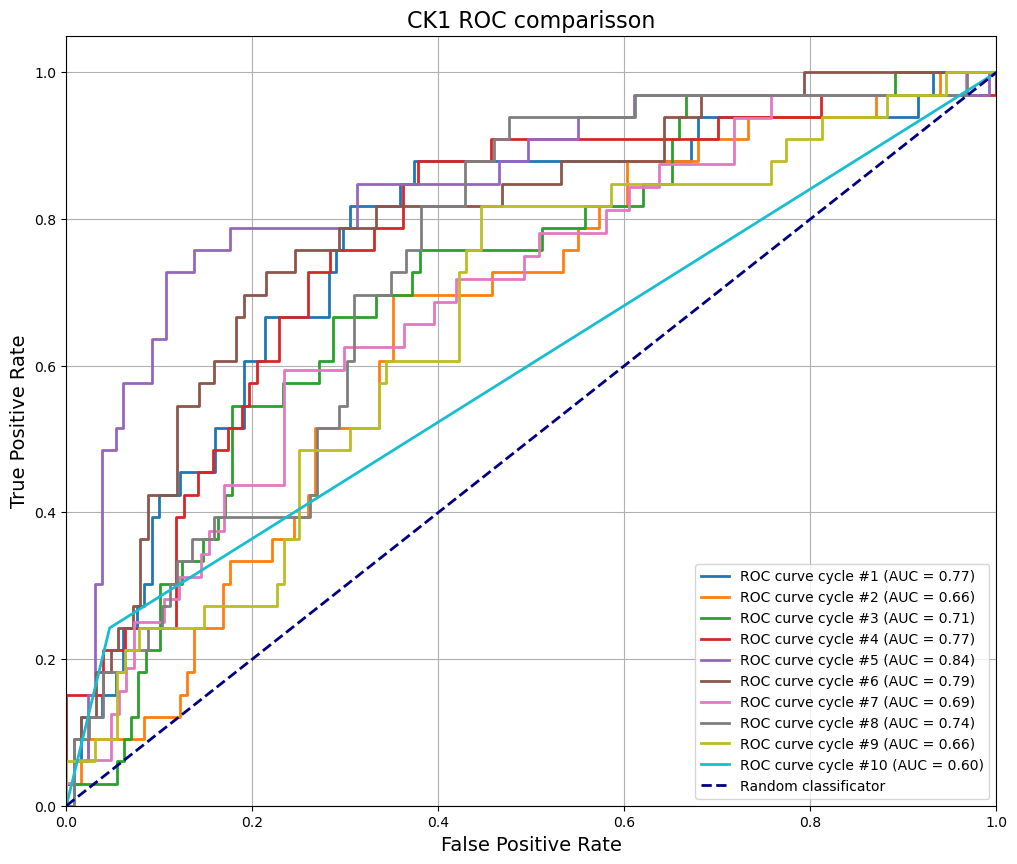

In [36]:


plt.figure(figsize=(12, 10))
for i in range(len(pred_test_mlp)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve cycle #{i + 1} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('CK1 ROC comparisson', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

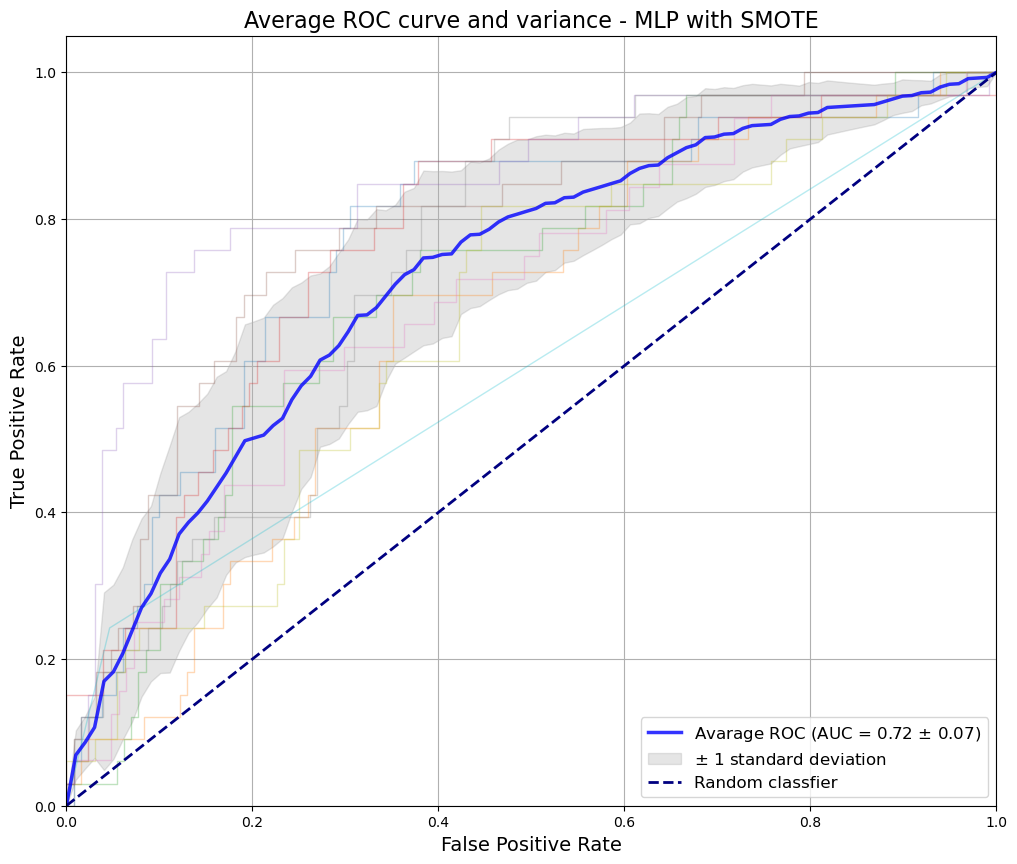

In [61]:
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
plt.figure(figsize=(12, 10))

for i in range(len(pred_test_mlp)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)


mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP with SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.savefig('roc_ck1.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
all_y3_knn =[]
mcc_list_knn = []
f1_list_knn = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_knn.append(y_test)
    f1_list_knn.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))
    mcc_list_knn.append(matthews_corrcoef(y_test, (pred_test_knn[i-1]>0.5)))

In [39]:
all_y3_mlp =[]
mcc_list_mlp = []
f1_list_mlp = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_mlp.append(y_test)
    mcc_list_mlp.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))
    f1_list_mlp.append(f1_score(y_test, (pred_test_mlp[i-1]>0.5)))

In [40]:
all_y3_svc =[]
mcc_list_svc = []
f1_list_svc = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_svc.append(y_test)
    f1_list_svc.append(f1_score(y_test, (pred_test_svc[i-1]>0.5)))
    mcc_list_svc.append(matthews_corrcoef(y_test, (pred_test_svc[i-1]>0.5)))

# WITHOUT SMOTE

In [41]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/modelshyperparameter_tuning_results'
csv_filename = os.path.join(output_dir, 'mlp_without_smote.csv')
df_existing_ws = pd.read_csv(csv_filename)
best_results_ws = df_existing_ws.iloc[:10]
best_results_ws = best_results_ws.iloc[:, 5:]
best_results_dicts_ws = []
for i,j in best_results_ws.iterrows():
    best_results_dicts_ws.append(dict(j))

In [42]:
best_results_dicts_ws

[{'dropout_frac': 0.2514922228056432,
  'patience': 15,
  'tol': 0.0010481131341546,
  'weight_decay': 0.0625055192527397,
  'n_epochs': 690,
  'batch_size': 512,
  'optimizer': 'RMSprop',
  'lr': 1e-05,
  'neuron_layers': '[200]'},
 {'dropout_frac': 0.5507664960597034,
  'patience': 87,
  'tol': 0.0007906043210907,
  'weight_decay': 0.0014563484775012,
  'n_epochs': 618,
  'batch_size': 256,
  'optimizer': 'AdamW',
  'lr': 1.0,
  'neuron_layers': '[2000, 1000]'},
 {'dropout_frac': 0.3181428654231315,
  'patience': 22,
  'tol': 4.094915062380427e-05,
  'weight_decay': 0.0004498432668969,
  'n_epochs': 409,
  'batch_size': 512,
  'optimizer': 'RMSprop',
  'lr': 1.0,
  'neuron_layers': '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]'},
 {'dropout_frac': 0.710047499040358,
  'patience': 177,
  'tol': 0.0005179474679231,
  'weight_decay': 0.0244205309454864,
  'n_epochs': 1307,
  'batch_size': 256,
  'optimizer': 'RMSprop',
  'lr': 1e-05,
  'neuron_layers': '[2000]'},
 {

In [43]:
df_existing_svc_ws = pd.read_csv("res/svc_without_smote_res_val_1.1.csv")
df_existing_svc_ws = df_existing_svc_ws.sort_values(by="mcc", ascending=False)
df_existing_svc_ws = df_existing_svc_ws.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_svc_ws = df_existing_svc_ws.iloc[:, :6]

best_results_svc_dicts_ws = []
for i,j in df_existing_svc_ws.iterrows():
    best_results_svc_dicts_ws.append(dict(j))

In [44]:
best_results_svc_dicts_ws

[{'C': 10.0,
  'coef0': 0.0,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 3,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 3,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 5,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 5,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 10.0,
  'coef0': 0.1,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 10.0,
  

In [45]:
df_existing_knn_ws = pd.read_csv("res/knn_without_smote_res_val_1.1.csv")
df_existing_knn_ws = df_existing_knn_ws.sort_values(by="mcc", ascending=False)
df_existing_knn_ws = df_existing_knn_ws.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_knn_ws = df_existing_knn_ws.iloc[:, :6]
best_results_knn_dicts_ws = []
for i,j in df_existing_knn_ws.iterrows():
    best_results_knn_dicts_ws.append(dict(j))

In [46]:
pred_val_svc_ws = []
pred_test_svc_ws = []

pred_val_knn_ws = []
pred_test_knn_ws = []

pred_val_mlp_ws = []
pred_test_mlp_ws = []

for i in range(1,11):
    print("-----", i, "-----")
    x1 = pd.read_csv(f"mod_data/X1.{i}", index_col="QSPRID")
    x2 = pd.read_csv(f"mod_data/X2.{i}", index_col="QSPRID")
    x3 = pd.read_csv(f"mod_data/X3.{i}", index_col="QSPRID")
    y1 = pd.read_csv(f"mod_data/y1.{i}", index_col="QSPRID")
    y2 = pd.read_csv(f"mod_data/y2.{i}", index_col="QSPRID")
    y3 = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    x1.columns = x1.columns.astype(str)
    x2.columns = x2.columns.astype(str)
    x3.columns = x3.columns.astype(str)

    imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
    x1 = imp_mean.fit_transform(x1)
    x2 = imp_mean.transform(x2)
    x3 = imp_mean.transform(x3)
    scaler = StandardScaler()
    scaler.fit(x1)
    x1 = scaler.transform(x1)
    x2 = scaler.transform(x2)
    x3 = scaler.transform(x3)


    pca = PCA(n_components=0.95, random_state = 69)
    pca.fit(x1)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cum_var >= 0.95) + 1
    pca = PCA(n_components=n_components, random_state = 69)
    x1 = pca.fit_transform(x1)
    x2 = pca.transform(x2)
    x3 = pca.transform(x3)

    y1 =  y1.values.ravel()
    y2 = y2.values.ravel()
    y3 = y3.values.ravel()
    display("SVC")
    best_mcc_this_run_svc_ws = -1
    best_val_results_this_run_svc_ws = []
    best_test_results_this_run_svc_ws = []
    for j in best_results_svc_dicts_ws:
        svc = SVC(**j, random_state=69)
        svc.fit(x1, y1)
        pred = svc.predict(x2)
        mcc = matthews_corrcoef(y2, pred > 0.5)
        if mcc > best_mcc_this_run_svc_ws:
            best_mcc_this_run_svc_ws = mcc
            best_val_results_this_run_svc_ws = svc.predict(x2)
            best_test_results_this_run_svc_ws = svc.predict(x3)
    pred_val_svc_ws.append(best_val_results_this_run_svc_ws)
    pred_test_svc_ws.append(best_test_results_this_run_svc_ws)

    best_mcc_this_run_ws = -1
    best_val_results_this_run_ws = []
    best_test_results_this_run_ws = []
    display("KNN")
    for j in best_results_knn_dicts_ws:
        knn = KNeighborsClassifier(**j)
        knn.fit(x1, y1)
        pred = knn.predict(x2)
        mcc = matthews_corrcoef(y2, pred)
        if mcc > best_mcc_this_run_ws:
            best_mcc_this_run_ws = mcc
            best_val_results_this_run_ws = knn.predict(x2)
            best_test_results_this_run_ws = knn.predict(x3)
    pred_val_knn_ws.append(best_val_results_this_run_ws)
    pred_test_knn_ws.append(best_test_results_this_run_ws)

    best_mcc_this_run_mlp_ws = -1
    best_val_results_this_run_mlp_ws = []
    best_test_results_this_run_mlp_ws = []
    display("MLP")
    for j in best_results_dicts_ws:
        if isinstance(j["optimizer"], str):
            j["optimizer"] = eval("optim." + j["optimizer"])
        if isinstance(j["neuron_layers"], str):
            j["neuron_layers"] = eval(j["neuron_layers"])
        j["batch_size"] = int(j["batch_size"])
        j["n_epochs"] = int(j["n_epochs"])
        mlp = MultiLayerPerceptron(x1.shape[1], n_class=1,act_fun=F.selu, device="cuda", **j, seed=69)
        mlp.fit(x1, y1, x2,y2)
        pred = mlp.predict(x2)>0.5
        mcc = matthews_corrcoef(y2, pred)
        if mcc > best_mcc_this_run_mlp_ws:
            best_mcc_this_run_ws = mcc
            best_val_results_this_run_mlp_ws = mlp.predict(x2)
            best_test_results_this_run_mlp_ws = mlp.predict(x3)
    pred_val_mlp_ws.append(best_val_results_this_run_mlp_ws)
    pred_test_mlp_ws.append(best_test_results_this_run_mlp_ws)


----- 1 -----


'SVC'

'KNN'

'MLP'

----- 2 -----


...

'MLP'

----- 10 -----


'SVC'

'KNN'

'MLP'

In [47]:
all_y3 =[]
mcc_list_mlp_ws = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3.append(y_test)
    mcc_list_mlp_ws.append(matthews_corrcoef(y_test, (np.array(pred_test_mlp_ws[i-1])>0.5)))

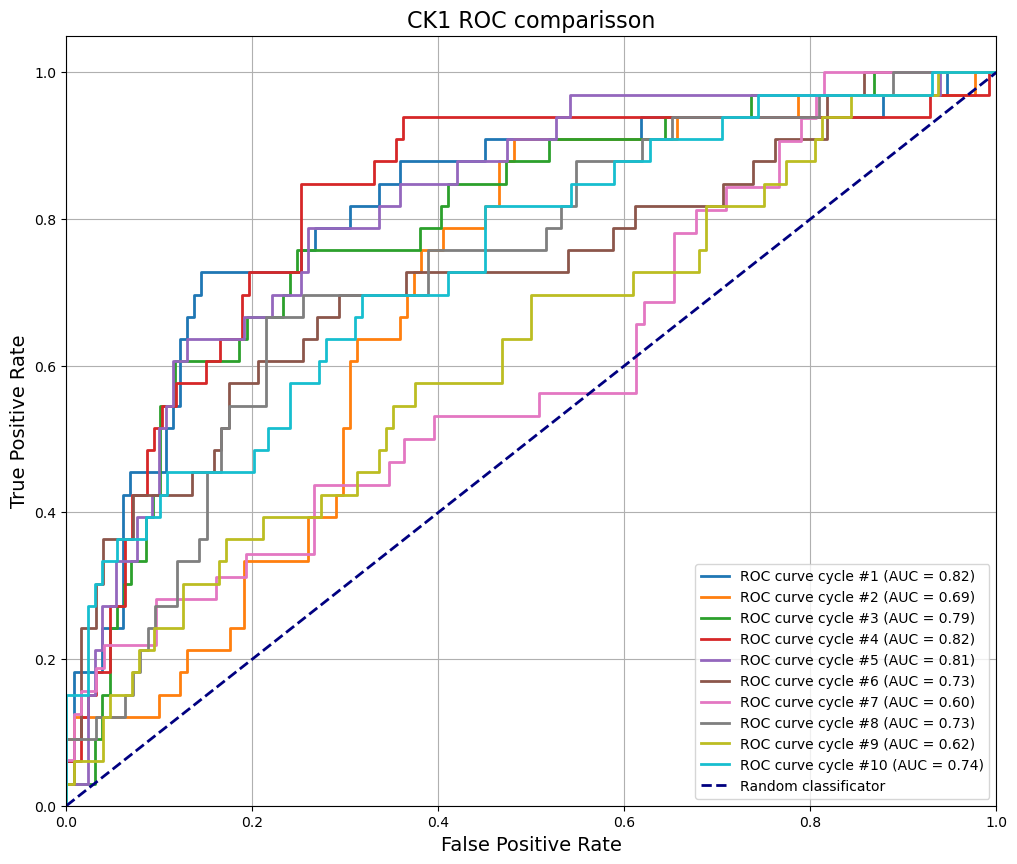

In [48]:
plt.figure(figsize=(12, 10))
for i in range(len(pred_test_mlp_ws)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp_ws[i]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve cycle #{i + 1} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('CK1 ROC comparisson', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

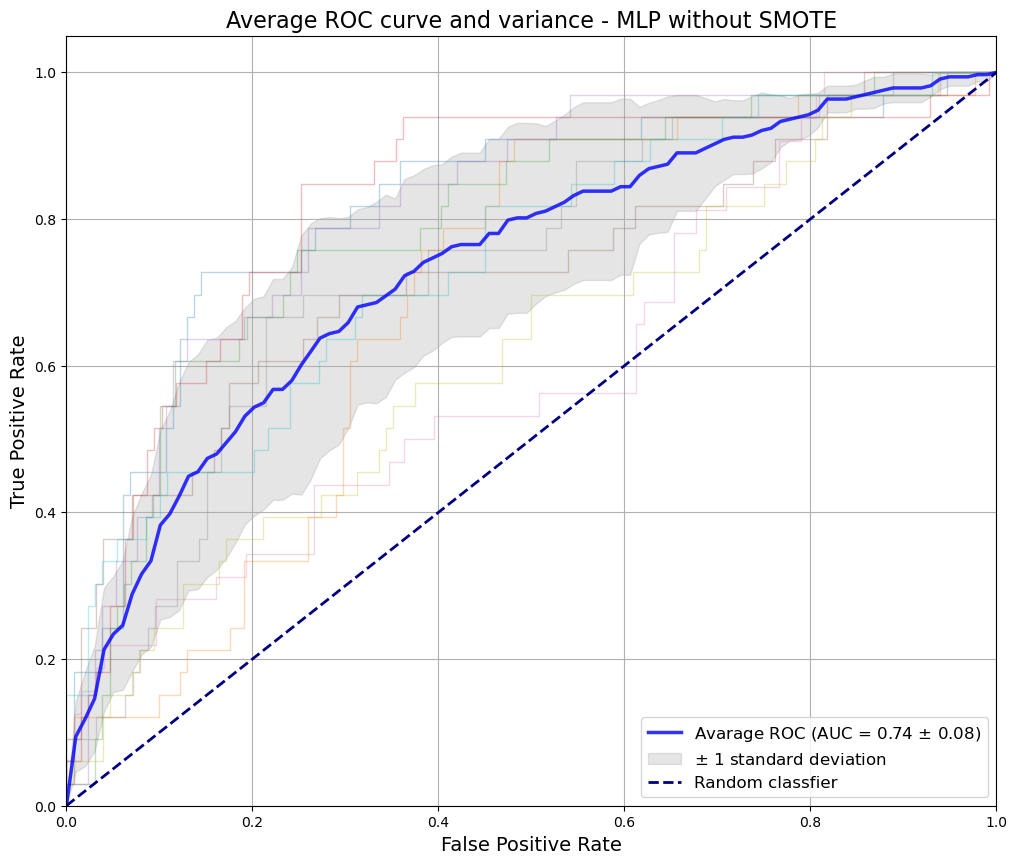

In [62]:
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
plt.figure(figsize=(12, 10))

for i in range(len(pred_test_mlp_ws)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp_ws[i]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)


mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP without SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.savefig('roc_ck1_ws.png', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
all_y3_knn_ws =[]
mcc_list_knn_ws = []
f1_list_knn_ws = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_knn_ws.append(y_test)
    f1_list_knn_ws.append(matthews_corrcoef(y_test, (pred_test_mlp_ws[i-1]>0.5)))
    mcc_list_knn_ws.append(matthews_corrcoef(y_test, (pred_test_knn_ws[i-1]>0.5)))

In [51]:
all_y3_mlp_ws =[]
mcc_list_mlp_ws = []
f1_list_mlp_ws = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_mlp_ws.append(y_test)
    mcc_list_mlp_ws.append(matthews_corrcoef(y_test, (pred_test_mlp_ws[i-1]>0.5)))
    f1_list_mlp_ws.append(f1_score(y_test, (pred_test_mlp_ws[i-1]>0.5)))

In [52]:
all_y3_svc_ws =[]
mcc_list_svc_ws = []
f1_list_svc_ws = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_svc_ws.append(y_test)
    f1_list_svc_ws.append(f1_score(y_test, (pred_test_svc_ws[i-1]>0.5)))
    mcc_list_svc_ws.append(matthews_corrcoef(y_test, (pred_test_svc_ws[i-1]>0.5)))

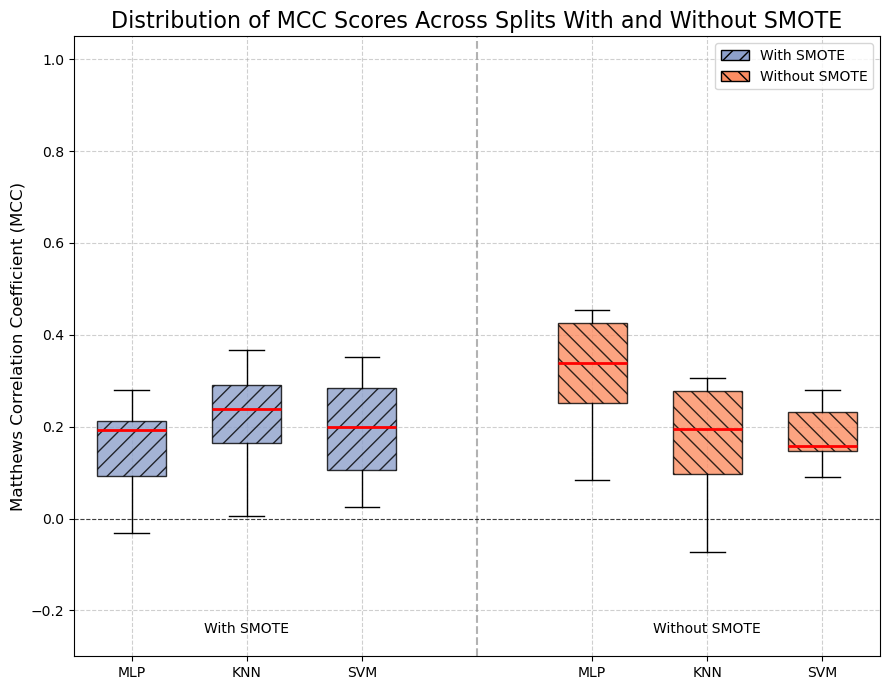

In [63]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(9, 7))

# Data
data = [mcc_list_mlp, mcc_list_knn, mcc_list_svc,
        mcc_list_mlp_ws, mcc_list_knn_ws, mcc_list_svc_ws]

# Vlastní pozice pro mezery mezi skupinami
positions = [1, 2, 3, 5, 6, 7]

# Vykreslení boxplotu na definovaných pozicích
bplot = plt.boxplot(data,
                    positions=positions,
                    patch_artist=True,
                    widths=0.6)

# Barvy a šrafování
smote_color = '#8da0cb'
non_smote_color = '#fc8d62'
smote_hatch = '//'
non_smote_hatch = '\\\\'
median_color = 'red'

# Úprava boxů
for i, box in enumerate(bplot['boxes']):
    if i < 3:
        box.set_facecolor(smote_color)
        box.set_hatch(smote_hatch)
    else:
        box.set_facecolor(non_smote_color)
        box.set_hatch(non_smote_hatch)
    box.set_edgecolor('black')
    box.set_alpha(0.8)

# Mediány
for median in bplot['medians']:
    median.set_color(median_color)
    median.set_linewidth(2)

# X-osa – popisky
plt.xticks([1, 2, 3, 5, 6, 7], ['MLP', 'KNN', 'SVM', 'MLP', 'KNN', 'SVM'])

# Oddělující čára mezi skupinami
plt.axvline(x=4, color='gray', linestyle='--', alpha=0.6)
plt.text(2, -0.25, 'With SMOTE', ha='center', fontsize=10)
plt.text(6, -0.25, 'Without SMOTE', ha='center', fontsize=10)

# Titulek a osy
plt.title('Distribution of MCC Scores Across Splits With and Without SMOTE', fontsize=16)
plt.ylabel('Matthews Correlation Coefficient (MCC)', fontsize=12)
plt.ylim([-0.3, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)

# Add a horizontal line at MCC = 0
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# Legenda
smote_patch = mpatches.Patch(facecolor=smote_color, edgecolor='black', hatch=smote_hatch, label='With SMOTE')
non_smote_patch = mpatches.Patch(facecolor=non_smote_color, edgecolor='black', hatch=non_smote_hatch, label='Without SMOTE')
plt.legend(handles=[smote_patch, non_smote_patch], loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('mcc_boxplot_ck1.png', dpi=300, bbox_inches='tight')
plt.show()


In [68]:
import pandas as pd
import numpy as np


def create_string(list_vals):
    return f"{np.mean(list_vals):.4f} ± {np.var(list_vals, ddof=1):.4f}"
# Příklad dat
data = {
    "Model": ["MLP", "MLP without SMOTE", "KNN", "KNN without SMOTE", "SVM", "SVM without SMOTE"],
    "F1": [create_string(f1_list_mlp), create_string(f1_list_mlp_ws), create_string(f1_list_knn), create_string(f1_list_knn_ws), create_string(f1_list_svc), create_string(f1_list_svc_ws)],
    "MCC": [create_string(mcc_list_mlp), create_string(mcc_list_mlp_ws), create_string(mcc_list_knn), create_string(mcc_list_knn_ws), create_string(mcc_list_svc), create_string(mcc_list_svc_ws)]
}


latex_code = df.to_latex(index=False, escape=False)
print(latex_code)

\begin{tabular}{lll}
\toprule
Model & F1 & MCC \\
\midrule
MLP & 0.2344 ± 0.0090 & 0.1591 ± 0.0096 \\
MLP without SMOTE & 0.4750 ± 0.0072 & 0.3194 ± 0.0153 \\
KNN & 0.1591 ± 0.0096 & 0.2165 ± 0.0141 \\
KNN without SMOTE & 0.3194 ± 0.0153 & 0.1665 ± 0.0174 \\
SVM & 0.2553 ± 0.0081 & 0.1993 ± 0.0135 \\
SVM without SMOTE & 0.2645 ± 0.0016 & 0.1829 ± 0.0041 \\
\bottomrule
\end{tabular}



In [64]:
print("With SMOTE")
print("MLP:")
print(mcc_list_mlp)
print("SVC:")
print(mcc_list_svc)
print("KNN:")
print(mcc_list_knn)
print("Without SMOTE:")
print("MLP:")
print(mcc_list_mlp_ws)
print("SVC:")
print(mcc_list_svc_ws)
print("KNN:")
print(mcc_list_knn_ws)

With SMOTE
MLP:
[0.1905198432638073, 0.05179579395086427, -0.032105718724445086, 0.2095969026693416, 0.21297173419325544, 0.1925493100306566, 0.2299084675051709, 0.1939441363585449, 0.060581636722749785, 0.28081438423200855]
SVC:
[0.1905198432638073, 0.0552086249707639, 0.07806259944213187, 0.1874534328026514, 0.2702239455289357, 0.28826493717718243, 0.340379871900178, 0.20603578944537568, 0.02550793665979526, 0.3508690026946019]
KNN:
[0.36669454141239677, 0.04346601729901178, 0.0061747965158871305, 0.1480815848997555, 0.2783846906609838, 0.2506970438905309, 0.2140462608328655, 0.22677216045305917, 0.2942074616088126, 0.33637220719324384]
Without SMOTE:
MLP:
[0.4309507286606523, 0.23262007442785054, 0.4550180504158235, 0.4331343918519374, 0.40715716396450186, 0.3043724033684387, 0.08429719791204525, 0.3374408043524879, 0.1706493835945859, 0.3383964338266785]
SVC:
[0.2460108552930142, 0.13604982582081104, 0.2787949980076138, 0.1471301684021711, 0.16942657217386592, 0.14732666664642455, 

In [65]:
print("Median:")
print("With SMOTE")
print("MLP:")
print(np.median(mcc_list_mlp))
print("SVC:")
print(np.median(mcc_list_svc))
print("KNN:")
print(np.median(mcc_list_knn))
print("Without SMOTE:")
print("MLP:")
print(np.median(mcc_list_mlp_ws))
print("SVC:")
print(np.median(mcc_list_svc_ws))
print("KNN:")
print(np.median(mcc_list_knn_ws))

Median:
With SMOTE
MLP:
0.19324672319460073
SVC:
0.1982778163545915
KNN:
0.23873460217179504
Without SMOTE:
MLP:
0.3379186190895832
SVC:
0.15837661941014525
KNN:
0.19586505948724964


In [66]:
print("Q1:")
print("With SMOTE")
print("MLP:")
print(np.percentile(mcc_list_mlp, 25))
print("SVC:")
print(np.percentile(mcc_list_svc, 25))
print("KNN:")
print(np.percentile(mcc_list_knn, 25))
print("Without SMOTE:")
print("MLP:")
print(np.percentile(mcc_list_mlp_ws, 25))
print("SVC:")
print(np.percentile(mcc_list_svc_ws, 25))
print("KNN:")
print(np.percentile(mcc_list_knn_ws, 25))


Q1:
With SMOTE
MLP:
0.09306618835801417
SVC:
0.10541030778226175
KNN:
0.164572753883033
Without SMOTE:
MLP:
0.2505581566629976
SVC:
0.14717929296323445
KNN:
0.09587927982107183


In [67]:
print("Q3:")
print("With SMOTE")
print("MLP:")
print(np.percentile(mcc_list_mlp, 75))
print("SVC:")
print(np.percentile(mcc_list_svc, 75))
print("KNN:")
print(np.percentile(mcc_list_knn, 75))
print("Without SMOTE:")
print("MLP:")
print(np.percentile(mcc_list_mlp_ws, 75))
print("SVC:")
print(np.percentile(mcc_list_svc_ws, 75))
print("KNN:")
print(np.percentile(mcc_list_knn_ws, 75))

Q3:
With SMOTE
MLP:
0.21212802631227698
SVC:
0.28375468926512076
KNN:
0.29025176887185544
Without SMOTE:
MLP:
0.4250023374866147
SVC:
0.23160043103226147
KNN:
0.27757666859099367
